In [1]:
!pip -q install geopandas rasterio folium scikit-learn torch shapely pyogrio tqdm

## 1. Cấu hình và import

In [2]:
import os, math, json, pickle, random, requests, unicodedata, warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.transform import xy
from shapely.geometry import box
import folium
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Bernoulli

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

ROOT_DIR = Path(".")
DATA_DIR = ROOT_DIR / "data"
CACHE_DIR = ROOT_DIR / "cache"
MODEL_DIR = ROOT_DIR / "models"
LOG_DIR = ROOT_DIR / "logs"
OUTPUT_DIR = ROOT_DIR / "outputs"

for d in [DATA_DIR, CACHE_DIR, MODEL_DIR, LOG_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

WORLDPOP_URL = "https://data.worldpop.org/GIS/Population_Density/Global_2000_2020_1km/2020/VNM/vnm_pd_2020_1km.tif"
GADM_LEVEL1_URL = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_VNM_1.json.zip"

POP_TIF = DATA_DIR / "vnm_pd_2020_1km.tif"
GADM_ZIP = DATA_DIR / "gadm41_VNM_1.json.zip"

PROJECTED_CRS = "EPSG:32648"

USE_ALL_PROVINCES = True
QUICK_PROVINCE_LIMIT = 12

N_POOL_PER_PROVINCE = 220
N_TRAIN_AGENTS = 50
SERVICE_RADIUS_KM = 3.0

MAX_DEMAND_CELLS_PER_PROVINCE = 2500
MIN_DEMAND_LEVEL_FOR_MODEL = 2

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

MAPPO_UPDATES = 900
ROLLOUT_BATCH_SIZE = 16
PPO_EPOCHS = 4
CLIP_EPS = 0.2

ACTOR_LR = 8e-4
CRITIC_LR = 1e-3
ENTROPY_COEF = 0.01
REWARD_SCALE = 100000.0

VAL_EVERY = 50
VAL_SCENARIOS_PER_PROVINCE = 2
TEST_SCENARIOS_PER_PROVINCE = 4

RANDOM_TRIALS = 200
POLICY_SAMPLES = 300
LOCAL_SEARCH_MAX_ITER = 5

REVENUE_PER_DEMAND = 50.0
DEFAULT_OPENING_COST = 10000.0
WAREHOUSE_CAPACITY = 2200.0

DISTANCE_COST = 3.0
UNSERVED_COST = 0.0
OVERLAP_COST = 700.0

TRANSPORT_MULTIPLIER_MIN = 0.7
TRANSPORT_MULTIPLIER_MAX = 1.3

OVER_CAPACITY_RATIO_MAX = 1.35
OVER_CAPACITY_PENALTY = 260000.0

UTILIZATION_BONUS = 50000.0

MIN_SERVED_DEMAND_PER_OPEN_WAREHOUSE = 400.0
MIN_REVENUE_TO_OPEN_COST_RATIO = 0.6
UNPRODUCTIVE_WAREHOUSE_PENALTY = 30000.0

print("Config ready")

DEVICE: cpu
Config ready


## 2. Tải dữ liệu GIS

In [3]:
def download_file(url, output_path):
    output_path = Path(output_path)
    if output_path.exists():
        print("Đã có file:", output_path)
        return
    print("Đang tải:", output_path)
    response = requests.get(url, stream=True)
    response.raise_for_status()
    with open(output_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
    print("Tải xong:", output_path)

download_file(WORLDPOP_URL, POP_TIF)
download_file(GADM_LEVEL1_URL, GADM_ZIP)

Đang tải: data/vnm_pd_2020_1km.tif
Tải xong: data/vnm_pd_2020_1km.tif
Đang tải: data/gadm41_VNM_1.json.zip
Tải xong: data/gadm41_VNM_1.json.zip


## 3. Load ranh giới và chia train/validation/test

In [4]:
def remove_accents(text):
    text = str(text)
    text = unicodedata.normalize("NFD", text)
    text = "".join(ch for ch in text if unicodedata.category(ch) != "Mn")
    return text.lower().strip()

def safe_name(text):
    s = remove_accents(text)
    for ch in [" ", "/", "\\", ".", ",", "-", "–", "—", "(", ")"]:
        s = s.replace(ch, "_")
    while "__" in s:
        s = s.replace("__", "_")
    return s.strip("_")

boundaries = gpd.read_file(f"zip://{GADM_ZIP}")
boundaries["province_name"] = boundaries["NAME_1"].astype(str)
boundaries["province_key"] = boundaries["province_name"].apply(safe_name)

display(boundaries[["province_name", "province_key"]].head(20))
print("Số tỉnh/thành:", len(boundaries))

def split_provinces(province_names, seed=42):
    names = list(province_names)
    rng = np.random.default_rng(seed)
    rng.shuffle(names)
    if not USE_ALL_PROVINCES:
        names = names[:QUICK_PROVINCE_LIMIT]
    n = len(names)
    n_train = max(1, int(n * TRAIN_RATIO))
    n_val = max(1, int(n * VAL_RATIO))
    n_test = max(1, n - n_train - n_val)
    return names[:n_train], names[n_train:n_train+n_val], names[n_train+n_val:n_train+n_val+n_test]

all_province_names = boundaries["province_name"].tolist()
TRAIN_PROVINCES, VAL_PROVINCES, TEST_PROVINCES = split_provinces(all_province_names, RANDOM_SEED)

split_df = pd.DataFrame({
    "split": ["train"] * len(TRAIN_PROVINCES) + ["val"] * len(VAL_PROVINCES) + ["test"] * len(TEST_PROVINCES),
    "province_name": TRAIN_PROVINCES + VAL_PROVINCES + TEST_PROVINCES
})
split_df.to_csv(LOG_DIR / "province_split.csv", index=False, encoding="utf-8-sig")

print("TRAIN:", len(TRAIN_PROVINCES), TRAIN_PROVINCES)
print("VAL:", len(VAL_PROVINCES), VAL_PROVINCES)
print("TEST:", len(TEST_PROVINCES), TEST_PROVINCES)

,province_name,province_key
0,AnGiang,angiang
1,BàRịa-VũngTàu,baria_vungtau
2,BắcGiang,bacgiang
3,BắcKạn,backan
4,BạcLiêu,baclieu
5,BắcNinh,bacninh
6,BếnTre,bentre
7,BìnhĐịnh,binhđinh
8,BìnhDương,binhduong
9,BìnhPhước,binhphuoc


Số tỉnh/thành: 63
TRAIN: 44 ['HồChíMinh', 'LàoCai', 'ĐồngNai', 'HàTĩnh', 'BìnhĐịnh', 'ĐiệnBiên', 'HậuGiang', 'TâyNinh', 'YênBái', 'NghệAn', 'SơnLa', 'BắcNinh', 'VĩnhLong', 'HảiDương', 'HoàBình', 'HàGiang', 'KiênGiang', 'GiaLai', 'ThanhHóa', 'QuảngNam', 'NinhThuận', 'TiềnGiang', 'QuảngNinh', 'BạcLiêu', 'HảiPhòng', 'ĐắkLắk', 'TuyênQuang', 'HàNội', 'NamĐịnh', 'BìnhPhước', 'TràVinh', 'KhánhHòa', 'TháiNguyên', 'ĐắkNông', 'BắcKạn', 'LaiChâu', 'HưngYên', 'BìnhThuận', 'SócTrăng', 'ThừaThiênHuế', 'BếnTre', 'LongAn', 'CàMau', 'PhúYên']
VAL: 9 ['NinhBình', 'HàNam', 'ĐồngTháp', 'LâmĐồng', 'AnGiang', 'QuảngNgãi', 'QuảngTrị', 'QuảngBình', 'CầnThơ']
TEST: 10 ['TháiBình', 'PhúThọ', 'ĐàNẵng', 'VĩnhPhúc', 'BắcGiang', 'LạngSơn', 'KonTum', 'BàRịa-VũngTàu', 'CaoBằng', 'BìnhDương']


## 4. Tạo demand cells và cache theo tỉnh/thành

In [5]:
def get_province_geometry(province_name):
    key = safe_name(province_name)
    row = boundaries[boundaries["province_key"] == key]
    if len(row) == 0:
        raise ValueError(f"Không tìm thấy tỉnh/thành: {province_name}")
    return row.iloc[[0]].copy()

def classify_by_quantile(values):
    q20, q40, q60, q80 = np.quantile(values, [0.2, 0.4, 0.6, 0.8])
    def classify(v):
        if np.isnan(v) or v <= 0:
            return 0
        if v <= q20:
            return 1
        if v <= q40:
            return 2
        if v <= q60:
            return 3
        if v <= q80:
            return 4
        return 5
    return np.vectorize(classify)

def build_demand_cells_from_clipped_raster(density, transform, max_cells=2500):
    valid_mask = ~np.isnan(density) & (density > 0)
    if valid_mask.sum() == 0:
        return None

    classifier = classify_by_quantile(density[valid_mask])
    level_array = classifier(density)
    rows, cols = np.where(valid_mask)

    records = []
    for r, c in zip(rows, cols):
        level = int(level_array[r, c])
        if level < MIN_DEMAND_LEVEL_FOR_MODEL:
            continue
        x_left, y_top = xy(transform, r, c, offset="ul")
        x_right, y_bottom = xy(transform, r, c, offset="lr")
        records.append({
            "density": float(density[r, c]),
            "demand_level": level,
            "geometry": box(x_left, y_bottom, x_right, y_top)
        })

    if len(records) == 0:
        return None

    demand_cells = gpd.GeoDataFrame(records, crs="EPSG:4326").reset_index(drop=True)
    p98 = np.percentile(demand_cells["density"], 98)
    demand_cells["demand"] = np.clip(demand_cells["density"] / max(p98, 1), 0, 1) * 100.0

    if len(demand_cells) > max_cells:
        weights = demand_cells["demand"].values
        weights = weights / weights.sum()
        idx = np.random.choice(len(demand_cells), size=max_cells, replace=False, p=weights)
        demand_cells = demand_cells.iloc[np.sort(idx)].reset_index(drop=True)

    demand_cells["cell_id"] = range(len(demand_cells))
    return demand_cells

def build_or_load_province_demand(province_name, force_rebuild=False):
    key = safe_name(province_name)
    cache_path = CACHE_DIR / f"{key}_demand_cells.pkl"
    if cache_path.exists() and not force_rebuild:
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    province_gdf = get_province_geometry(province_name)
    with rasterio.open(POP_TIF) as src:
        province_in_raster_crs = province_gdf.to_crs(src.crs)
        out_image, out_transform = mask(src, province_in_raster_crs.geometry, crop=True)
        density = out_image[0].astype(float)
        if src.nodata is not None:
            density[density == src.nodata] = np.nan
    density[density < 0] = np.nan

    demand_cells = build_demand_cells_from_clipped_raster(
        density, out_transform, max_cells=MAX_DEMAND_CELLS_PER_PROVINCE
    )
    if demand_cells is None or len(demand_cells) < N_TRAIN_AGENTS:
        print("Bỏ qua vì demand cells quá ít:", province_name)
        return None

    data = {"province_name": province_name, "province_key": key, "demand_cells": demand_cells}
    with open(cache_path, "wb") as f:
        pickle.dump(data, f)
    return data

ALL_USED_PROVINCES = TRAIN_PROVINCES + VAL_PROVINCES + TEST_PROVINCES

READY_PROVINCES = []
for province in tqdm(ALL_USED_PROVINCES, desc="Demand cache"):
    data = build_or_load_province_demand(province)
    if data is not None:
        READY_PROVINCES.append(province)

TRAIN_PROVINCES = [p for p in TRAIN_PROVINCES if p in READY_PROVINCES]
VAL_PROVINCES = [p for p in VAL_PROVINCES if p in READY_PROVINCES]
TEST_PROVINCES = [p for p in TEST_PROVINCES if p in READY_PROVINCES]

print("TRAIN ready:", len(TRAIN_PROVINCES))
print("VAL ready:", len(VAL_PROVINCES))
print("TEST ready:", len(TEST_PROVINCES))

Demand cache:   0%|          | 0/63 [00:00<?, ?it/s]

TRAIN ready: 44
VAL ready: 9
TEST ready: 10


## 5. Tạo warehouse pool và ma trận GIS theo tỉnh/thành

In [6]:
def create_warehouse_pool_from_demand_cells(demand_cells, n_pool=220):
    cent = demand_cells.copy()
    cent["centroid"] = cent.geometry.centroid
    cent["lat"] = cent["centroid"].y
    cent["lon"] = cent["centroid"].x
    high_demand = cent[cent["demand_level"] >= 3].copy()
    if len(high_demand) < N_TRAIN_AGENTS:
        high_demand = cent.copy()

    n_pool = min(n_pool, len(high_demand))
    n_pool = max(N_TRAIN_AGENTS, n_pool)
    if len(high_demand) < n_pool:
        n_pool = len(high_demand)

    X = high_demand[["lat", "lon"]].values
    weights = high_demand["demand"].values
    kmeans = KMeans(n_clusters=n_pool, random_state=RANDOM_SEED, n_init=10)
    kmeans.fit(X, sample_weight=weights)

    pool = pd.DataFrame(kmeans.cluster_centers_, columns=["lat", "lon"])
    pool["warehouse_id"] = [f"Pool_Kho_{i+1}" for i in range(len(pool))]
    pool["opening_cost"] = DEFAULT_OPENING_COST
    pool["capacity"] = WAREHOUSE_CAPACITY
    return pool

def build_warehouse_buffers(warehouses, service_radius_km):
    warehouse_points = gpd.GeoDataFrame(
        warehouses.copy(),
        geometry=gpd.points_from_xy(warehouses["lon"], warehouses["lat"]),
        crs="EPSG:4326"
    )
    warehouse_meter = warehouse_points.to_crs(PROJECTED_CRS)
    warehouse_buffers = warehouse_meter.copy()
    warehouse_buffers["geometry"] = warehouse_meter.geometry.buffer(service_radius_km * 1000)
    return warehouse_points, warehouse_buffers

def compute_area_coverage_matrix(demand_cells, warehouse_buffers):
    demand_meter = demand_cells.to_crs(PROJECTED_CRS).copy()
    demand_meter["cell_area"] = demand_meter.geometry.area
    coverage_matrix = np.zeros((len(demand_meter), len(warehouse_buffers)), dtype=np.float32)
    sindex = demand_meter.sindex

    for j, wh in warehouse_buffers.iterrows():
        possible_idx = list(sindex.query(wh.geometry, predicate="intersects"))
        for i in possible_idx:
            inter = demand_meter.iloc[i].geometry.intersection(wh.geometry)
            if inter.is_empty:
                continue
            ratio = inter.area / demand_meter.iloc[i]["cell_area"]
            coverage_matrix[i, j] = min(max(ratio, 0), 1)
    return coverage_matrix

def haversine_matrix(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(np.array(lat1))[:, None]
    lon1 = np.radians(np.array(lon1))[:, None]
    lat2 = np.radians(np.array(lat2))[None, :]
    lon2 = np.radians(np.array(lon2))[None, :]
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def compute_distance_matrix(demand_cells, warehouses):
    cent = demand_cells.copy()
    cent["centroid"] = cent.geometry.centroid
    cent["lat"] = cent["centroid"].y
    cent["lon"] = cent["centroid"].x
    return haversine_matrix(
        cent["lat"].values, cent["lon"].values,
        warehouses["lat"].values, warehouses["lon"].values
    ).astype(np.float32)

def equal_circle_overlap_ratio(distance_km, radius_km):
    d = np.array(distance_km, dtype=np.float32)
    r = float(radius_km)
    ratio = np.zeros_like(d, dtype=np.float32)
    ratio[d <= 1e-9] = 1.0
    mask = (d > 1e-9) & (d < 2 * r)
    dm = d[mask]
    inter_area = 2 * r * r * np.arccos(dm / (2 * r)) - 0.5 * dm * np.sqrt(np.maximum(4 * r * r - dm * dm, 0))
    ratio[mask] = inter_area / (math.pi * r * r)
    return ratio

def compute_warehouse_overlap_matrix_fast(warehouses):
    wh_dist = haversine_matrix(
        warehouses["lat"].values, warehouses["lon"].values,
        warehouses["lat"].values, warehouses["lon"].values
    )
    overlap = equal_circle_overlap_ratio(wh_dist, SERVICE_RADIUS_KM)
    np.fill_diagonal(overlap, 0.0)
    return overlap.astype(np.float32)

def build_or_load_province_full_cache(province_name, force_rebuild=False):
    key = safe_name(province_name)
    cache_path = CACHE_DIR / f"{key}_full_cache.pkl"
    if cache_path.exists() and not force_rebuild:
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    demand_data = build_or_load_province_demand(province_name)
    if demand_data is None:
        return None
    demand_cells = demand_data["demand_cells"]

    pool = create_warehouse_pool_from_demand_cells(demand_cells, n_pool=N_POOL_PER_PROVINCE)
    if len(pool) < N_TRAIN_AGENTS:
        print("Bỏ qua vì warehouse pool quá ít:", province_name)
        return None

    _, buffers = build_warehouse_buffers(pool, SERVICE_RADIUS_KM)
    coverage = compute_area_coverage_matrix(demand_cells, buffers)
    distance = compute_distance_matrix(demand_cells, pool)
    overlap = compute_warehouse_overlap_matrix_fast(pool)

    full_cache = {
        "province_name": province_name,
        "province_key": key,
        "demand_cells": demand_cells,
        "warehouse_pool": pool,
        "coverage_matrix": coverage,
        "distance_matrix": distance,
        "overlap_matrix": overlap
    }
    with open(cache_path, "wb") as f:
        pickle.dump(full_cache, f)
    return full_cache

READY_FULL_PROVINCES = []
for province in tqdm(ALL_USED_PROVINCES, desc="Full cache"):
    data = build_or_load_province_full_cache(province)
    if data is not None:
        READY_FULL_PROVINCES.append(province)

TRAIN_PROVINCES = [p for p in TRAIN_PROVINCES if p in READY_FULL_PROVINCES]
VAL_PROVINCES = [p for p in VAL_PROVINCES if p in READY_FULL_PROVINCES]
TEST_PROVINCES = [p for p in TEST_PROVINCES if p in READY_FULL_PROVINCES]

print("TRAIN:", len(TRAIN_PROVINCES), TRAIN_PROVINCES)
print("VAL:", len(VAL_PROVINCES), VAL_PROVINCES)
print("TEST:", len(TEST_PROVINCES), TEST_PROVINCES)

Full cache:   0%|          | 0/63 [00:00<?, ?it/s]

TRAIN: 44 ['HồChíMinh', 'LàoCai', 'ĐồngNai', 'HàTĩnh', 'BìnhĐịnh', 'ĐiệnBiên', 'HậuGiang', 'TâyNinh', 'YênBái', 'NghệAn', 'SơnLa', 'BắcNinh', 'VĩnhLong', 'HảiDương', 'HoàBình', 'HàGiang', 'KiênGiang', 'GiaLai', 'ThanhHóa', 'QuảngNam', 'NinhThuận', 'TiềnGiang', 'QuảngNinh', 'BạcLiêu', 'HảiPhòng', 'ĐắkLắk', 'TuyênQuang', 'HàNội', 'NamĐịnh', 'BìnhPhước', 'TràVinh', 'KhánhHòa', 'TháiNguyên', 'ĐắkNông', 'BắcKạn', 'LaiChâu', 'HưngYên', 'BìnhThuận', 'SócTrăng', 'ThừaThiênHuế', 'BếnTre', 'LongAn', 'CàMau', 'PhúYên']
VAL: 9 ['NinhBình', 'HàNam', 'ĐồngTháp', 'LâmĐồng', 'AnGiang', 'QuảngNgãi', 'QuảngTrị', 'QuảngBình', 'CầnThơ']
TEST: 10 ['TháiBình', 'PhúThọ', 'ĐàNẵng', 'VĩnhPhúc', 'BắcGiang', 'LạngSơn', 'KonTum', 'BàRịa-VũngTàu', 'CaoBằng', 'BìnhDương']


## 6. Reward / Profit Evaluator

In [7]:
def prepare_env(demand_cells, warehouses, coverage_matrix, distance_matrix, overlap_matrix):
    warehouses = warehouses.copy()
    if "opening_cost" not in warehouses.columns:
        warehouses["opening_cost"] = DEFAULT_OPENING_COST
    if "capacity" not in warehouses.columns:
        warehouses["capacity"] = WAREHOUSE_CAPACITY

    demand = demand_cells["demand"].values.astype(np.float32)
    demand_norm = demand / max(float(demand.max()), 1.0)
    transport_multiplier = TRANSPORT_MULTIPLIER_MAX - (
        (TRANSPORT_MULTIPLIER_MAX - TRANSPORT_MULTIPLIER_MIN) * demand_norm
    )

    return {
        "demand": demand,
        "demand_level": demand_cells["demand_level"].values.astype(np.int32),
        "density": demand_cells["density"].values.astype(np.float32),
        "coverage_matrix": coverage_matrix.astype(np.float32),
        "distance_matrix": distance_matrix.astype(np.float32),
        "warehouse_overlap_matrix": overlap_matrix.astype(np.float32),
        "opening_cost": warehouses["opening_cost"].values.astype(np.float32),
        "warehouse_capacity": warehouses["capacity"].values.astype(np.float32),
        "total_demand": float(demand.sum()),
        "transport_multiplier": np.clip(transport_multiplier, TRANSPORT_MULTIPLIER_MIN, TRANSPORT_MULTIPLIER_MAX).astype(np.float32)
    }

def evaluate_solution(open_mask, env):
    open_mask = np.array(open_mask).astype(bool)
    n_open = int(open_mask.sum())
    demand = env["demand"]
    total_demand = env["total_demand"]

    if n_open == 0:
        return -999999999.0, {
            "n_open": 0, "served_demand": 0.0, "unserved_demand": total_demand,
            "coverage_ratio": 0.0, "unserved_ratio": 1.0, "capacity_ratio": 0.0,
            "utilization_ratio": 0.0, "revenue": 0.0, "opening_cost": 0.0,
            "distance_cost": 0.0, "unserved_cost": 0.0, "overlap_cost": 0.0,
            "over_capacity_cost": 0.0, "utilization_bonus": 0.0,
            "unproductive_warehouse_cost": 0.0,
            "avg_served_demand_per_open_warehouse": 0.0,
            "min_served_demand_by_open_warehouse": 0.0,
            "avg_transport_multiplier": 0.0, "profit": -999999999.0
        }

    coverage_matrix = env["coverage_matrix"]
    distance_matrix = env["distance_matrix"]
    opening_cost_arr = env["opening_cost"]
    capacity_arr = env["warehouse_capacity"]
    transport_multiplier = env["transport_multiplier"]

    selected_coverage = coverage_matrix[:, open_mask]
    served_ratio = np.clip(selected_coverage.sum(axis=1), 0, 1)
    served_demand = demand * served_ratio
    served_demand_total = float(served_demand.sum())

    unserved_demand = float(total_demand - served_demand_total)
    coverage_ratio = served_demand_total / max(total_demand, 1)
    unserved_ratio = unserved_demand / max(total_demand, 1)

    coverage_sum = selected_coverage.sum(axis=1)
    allocation_weights = np.zeros_like(selected_coverage)
    valid_rows = coverage_sum > 0
    allocation_weights[valid_rows] = selected_coverage[valid_rows] / coverage_sum[valid_rows, None]

    served_demand_by_open_warehouse = (allocation_weights * served_demand[:, None]).sum(axis=0)
    revenue_by_open_warehouse = served_demand_by_open_warehouse * REVENUE_PER_DEMAND
    revenue = served_demand_total * REVENUE_PER_DEMAND

    open_cost_by_warehouse = opening_cost_arr[open_mask]
    opening_cost = float(open_cost_by_warehouse.sum())

    open_distance = distance_matrix[:, open_mask].copy()
    open_coverage = coverage_matrix[:, open_mask].copy()
    open_distance[open_coverage <= 0] = np.inf
    nearest_distance = np.min(open_distance, axis=1)
    nearest_distance[np.isinf(nearest_distance)] = 0

    distance_cost = float(np.sum(served_demand * nearest_distance * DISTANCE_COST * transport_multiplier))
    unserved_cost = unserved_demand * UNSERVED_COST

    if n_open > 1:
        wh_overlap = env["warehouse_overlap_matrix"][np.ix_(open_mask, open_mask)]
        overlap_score = float(wh_overlap.sum() / 2)
    else:
        overlap_score = 0.0
    overlap_cost = overlap_score * OVERLAP_COST

    total_capacity = float(capacity_arr[open_mask].sum())
    capacity_ratio = total_capacity / max(served_demand_total, 1)
    utilization_ratio = served_demand_total / max(total_capacity, 1)

    if capacity_ratio > OVER_CAPACITY_RATIO_MAX:
        over_capacity_cost = ((capacity_ratio - OVER_CAPACITY_RATIO_MAX) ** 2) * OVER_CAPACITY_PENALTY
    else:
        over_capacity_cost = 0.0

    utilization_bonus = utilization_ratio * UTILIZATION_BONUS

    low_demand_gap = np.maximum(0, MIN_SERVED_DEMAND_PER_OPEN_WAREHOUSE - served_demand_by_open_warehouse)
    low_demand_penalty = (low_demand_gap / MIN_SERVED_DEMAND_PER_OPEN_WAREHOUSE).sum() * UNPRODUCTIVE_WAREHOUSE_PENALTY

    required_revenue = open_cost_by_warehouse * MIN_REVENUE_TO_OPEN_COST_RATIO
    low_revenue_gap = np.maximum(0, required_revenue - revenue_by_open_warehouse)
    low_revenue_penalty = (low_revenue_gap / np.maximum(required_revenue, 1)).sum() * UNPRODUCTIVE_WAREHOUSE_PENALTY
    unproductive_warehouse_cost = float(low_demand_penalty + low_revenue_penalty)

    if served_demand_total > 0:
        avg_transport_multiplier = float(np.average(transport_multiplier, weights=np.maximum(served_demand, 1e-6)))
    else:
        avg_transport_multiplier = 0.0

    profit = revenue + utilization_bonus - opening_cost - distance_cost - unserved_cost - overlap_cost - over_capacity_cost - unproductive_warehouse_cost

    info = {
        "n_open": n_open,
        "served_demand": float(served_demand_total),
        "unserved_demand": float(unserved_demand),
        "coverage_ratio": float(coverage_ratio),
        "unserved_ratio": float(unserved_ratio),
        "capacity_ratio": float(capacity_ratio),
        "utilization_ratio": float(utilization_ratio),
        "revenue": float(revenue),
        "opening_cost": float(opening_cost),
        "distance_cost": float(distance_cost),
        "unserved_cost": float(unserved_cost),
        "overlap_cost": float(overlap_cost),
        "over_capacity_cost": float(over_capacity_cost),
        "utilization_bonus": float(utilization_bonus),
        "unproductive_warehouse_cost": float(unproductive_warehouse_cost),
        "avg_served_demand_per_open_warehouse": float(served_demand_by_open_warehouse.mean()),
        "min_served_demand_by_open_warehouse": float(served_demand_by_open_warehouse.min()),
        "avg_transport_multiplier": avg_transport_multiplier,
        "profit": float(profit)
    }
    return float(profit), info

## 7. Feature và scenario sampling

In [8]:
def build_warehouse_features(warehouses, env):
    demand = env["demand"]
    demand_level = env["demand_level"]
    coverage = env["coverage_matrix"]
    dist = env["distance_matrix"]
    wh_overlap = env["warehouse_overlap_matrix"]
    opening_cost = env["opening_cost"]
    capacity = env["warehouse_capacity"]
    transport_multiplier = env["transport_multiplier"]

    local_served_demand = (coverage * demand[:, None]).sum(axis=0)

    max_demand_level = []
    weighted_avg_distance = []
    weighted_transport_multiplier = []

    for j in range(len(warehouses)):
        covered = coverage[:, j] > 0
        if covered.sum() == 0:
            max_demand_level.append(0)
            weighted_avg_distance.append(SERVICE_RADIUS_KM)
            weighted_transport_multiplier.append(TRANSPORT_MULTIPLIER_MAX)
        else:
            max_demand_level.append(int(demand_level[covered].max()))
            weights = demand[covered] * coverage[covered, j]
            if weights.sum() == 0:
                weighted_avg_distance.append(SERVICE_RADIUS_KM)
                weighted_transport_multiplier.append(TRANSPORT_MULTIPLIER_MAX)
            else:
                weighted_avg_distance.append(float(np.average(dist[covered, j], weights=weights)))
                weighted_transport_multiplier.append(float(np.average(transport_multiplier[covered], weights=weights)))

    features = pd.DataFrame({
        "local_served_demand": local_served_demand,
        "max_demand_level": np.array(max_demand_level),
        "weighted_avg_distance": np.array(weighted_avg_distance),
        "weighted_transport_multiplier": np.array(weighted_transport_multiplier),
        "overlap_with_others": wh_overlap.sum(axis=1),
        "opening_cost": opening_cost,
        "capacity": capacity
    })

    features["local_served_demand_norm"] = features["local_served_demand"] / max(features["local_served_demand"].max(), 1)
    features["max_demand_level_norm"] = features["max_demand_level"] / 5
    features["weighted_avg_distance_norm"] = (features["weighted_avg_distance"] / SERVICE_RADIUS_KM).clip(0, 1)
    features["transport_multiplier_norm"] = ((features["weighted_transport_multiplier"] - TRANSPORT_MULTIPLIER_MIN) / max(TRANSPORT_MULTIPLIER_MAX - TRANSPORT_MULTIPLIER_MIN, 1e-6)).clip(0, 1)
    features["overlap_with_others_norm"] = features["overlap_with_others"] / max(features["overlap_with_others"].max(), 1)
    features["opening_cost_norm"] = features["opening_cost"] / max(features["opening_cost"].max(), 1)
    features["capacity_norm"] = features["capacity"] / max(features["capacity"].max(), 1)

    feature_cols = [
        "local_served_demand_norm", "max_demand_level_norm", "weighted_avg_distance_norm",
        "transport_multiplier_norm", "overlap_with_others_norm", "opening_cost_norm", "capacity_norm"
    ]
    return features, feature_cols

def get_full_cache(province_name):
    return build_or_load_province_full_cache(province_name)

def build_env_from_pool_sample(province_name, selected_idx):
    cache = get_full_cache(province_name)
    demand_cells = cache["demand_cells"]
    pool = cache["warehouse_pool"]
    warehouses = pool.iloc[selected_idx].copy().reset_index(drop=True)
    coverage = cache["coverage_matrix"][:, selected_idx]
    distance = cache["distance_matrix"][:, selected_idx]
    overlap = cache["overlap_matrix"][np.ix_(selected_idx, selected_idx)]
    env = prepare_env(demand_cells, warehouses, coverage, distance, overlap)
    features, feature_cols = build_warehouse_features(warehouses, env)
    return warehouses, env, features, feature_cols

def sample_scenario(province_list):
    province = random.choice(province_list)
    cache = get_full_cache(province)
    pool = cache["warehouse_pool"]
    selected_idx = np.random.choice(len(pool), size=N_TRAIN_AGENTS, replace=False)
    selected_idx = np.sort(selected_idx)
    warehouses, env, features, feature_cols = build_env_from_pool_sample(province, selected_idx)
    return province, warehouses, env, features, feature_cols

tmp_province, tmp_w, tmp_env, tmp_features, feature_cols = sample_scenario(TRAIN_PROVINCES)
OBS_DIM = len(feature_cols)
print("Sample province:", tmp_province)
print("OBS_DIM:", OBS_DIM)
display(tmp_features.head())

Sample province: BếnTre
OBS_DIM: 7


,local_served_demand,max_demand_level,weighted_avg_distance,weighted_transport_multiplier,overlap_with_others,opening_cost,capacity,local_served_demand_norm,max_demand_level_norm,weighted_avg_distance_norm,transport_multiplier_norm,overlap_with_others_norm,opening_cost_norm,capacity_norm
0,1389.596191,5,2.256430,0.911691,1.183523,10000.0,2200.0,0.733412,1.0,0.752143,0.352818,0.793169,1.0,1.0
1,1227.644165,5,1.948399,0.993562,0.931450,10000.0,2200.0,0.647935,1.0,0.649466,0.489271,0.624236,1.0,1.0
2,1139.548340,5,1.720886,0.965361,1.026690,10000.0,2200.0,0.601439,1.0,0.573629,0.442269,0.688064,1.0,1.0
3,1288.744507,5,1.926904,0.972872,0.396710,10000.0,2200.0,0.680183,1.0,0.642301,0.454787,0.265866,1.0,1.0
4,320.009949,4,1.735588,1.216340,0.000000,10000.0,2200.0,0.168897,0.8,0.578529,0.860567,0.000000,1.0,1.0


## 8. MAPPO networks

In [9]:
class SharedActor(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, obs):
        return self.net(obs).squeeze(-1)

class CentralizedCritic(nn.Module):
    def __init__(self, n_agents, obs_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_agents * obs_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, global_state):
        return self.net(global_state).squeeze(-1)

actor = SharedActor(OBS_DIM).to(DEVICE)
critic = CentralizedCritic(N_TRAIN_AGENTS, OBS_DIM).to(DEVICE)

actor_optimizer = optim.Adam(actor.parameters(), lr=ACTOR_LR)
critic_optimizer = optim.Adam(critic.parameters(), lr=CRITIC_LR)

## 9. Baselines, MAPPO inference và Local Search

In [10]:
def random_search_baseline(env, num_trials=200):
    n = env["coverage_matrix"].shape[1]
    best_reward = -999999999
    best_actions = None
    best_info = None
    for _ in range(num_trials):
        actions = np.random.binomial(1, 0.5, size=n)
        if actions.sum() == 0:
            actions[np.random.randint(0, n)] = 1
        reward, info = evaluate_solution(actions, env)
        if reward > best_reward:
            best_reward = reward
            best_actions = actions.copy()
            best_info = info.copy()
    return best_actions, best_reward, best_info

def greedy_baseline(features, env):
    n = len(features)
    raw_score = (
        features["local_served_demand"].values * REVENUE_PER_DEMAND
        - features["opening_cost"].values
        - features["weighted_avg_distance"].values * DISTANCE_COST * 100.0
        - features["overlap_with_others"].values * OVERLAP_COST * 0.1
    )
    order = np.argsort(-raw_score)
    candidate_ks = sorted(set([1, 2, 3, 5, max(1, int(n * 0.15)), max(1, int(n * 0.25)), max(1, int(n * 0.35)), max(1, int(n * 0.50)), n]))
    best_reward = -999999999
    best_actions = None
    best_info = None
    for k in candidate_ks:
        actions = np.zeros(n, dtype=int)
        actions[order[:k]] = 1
        reward, info = evaluate_solution(actions, env)
        if reward > best_reward:
            best_reward = reward
            best_actions = actions.copy()
            best_info = info.copy()
    return best_actions, best_reward, best_info

def cooperative_local_search(actions, env, max_iter=5):
    actions = np.array(actions).astype(int).copy()
    if actions.sum() == 0:
        actions[np.random.randint(0, len(actions))] = 1
    best_reward, best_info = evaluate_solution(actions, env)
    for _ in range(max_iter):
        improved = False
        for i in range(len(actions)):
            trial = actions.copy()
            trial[i] = 1 - trial[i]
            if trial.sum() == 0:
                continue
            reward, info = evaluate_solution(trial, env)
            if reward > best_reward:
                actions = trial
                best_reward = reward
                best_info = info
                improved = True
        if not improved:
            break
    return actions, best_reward, best_info

def mappo_decide(features, env, n_samples=300):
    obs_np = features[feature_cols].values.astype(np.float32)
    obs = torch.tensor(obs_np, dtype=torch.float32, device=DEVICE)
    actor.eval()
    with torch.no_grad():
        probs = actor(obs).detach().cpu().numpy()
    best_reward = -999999999
    best_actions = None
    best_info = None
    candidates = []

    actions_threshold = (probs >= 0.5).astype(int)
    if actions_threshold.sum() == 0:
        actions_threshold[np.argmax(probs)] = 1
    candidates.append(actions_threshold)

    sorted_idx = np.argsort(-probs)
    n = len(probs)
    candidate_ks = sorted(set([1, 2, 3, 5, max(1, int(n * 0.15)), max(1, int(n * 0.25)), max(1, int(n * 0.35)), max(1, int(n * 0.50)), n]))
    for k in candidate_ks:
        actions_topk = np.zeros(n, dtype=int)
        actions_topk[sorted_idx[:k]] = 1
        candidates.append(actions_topk)

    prob_sum = probs.sum()
    sample_prob = np.ones(n) / n if prob_sum <= 1e-9 else probs / prob_sum

    for _ in range(n_samples):
        if np.random.rand() < 0.5:
            actions = np.random.binomial(1, probs)
            if actions.sum() == 0:
                actions[np.argmax(probs)] = 1
        else:
            k = np.random.randint(1, n + 1)
            selected = np.random.choice(n, size=k, replace=False, p=sample_prob)
            actions = np.zeros(n, dtype=int)
            actions[selected] = 1
        candidates.append(actions)

    for actions in candidates:
        reward, info = evaluate_solution(actions, env)
        if reward > best_reward:
            best_reward = reward
            best_actions = actions.copy()
            best_info = info.copy()
    actor.train()
    return best_actions, best_reward, best_info, probs

## 10. Validation / Test evaluator

In [11]:
def aggregate_infos(rows):
    if len(rows) == 0:
        return {}
    df = pd.DataFrame(rows)
    out = {}
    for c in df.columns:
        if pd.api.types.is_numeric_dtype(df[c]):
            out[c] = float(df[c].mean())
    return out

def evaluate_methods_on_provinces(province_list, scenarios_per_province=2, policy_samples=300):
    rows = []
    for province in province_list:
        cache = get_full_cache(province)
        pool = cache["warehouse_pool"]
        for s in range(scenarios_per_province):
            selected_idx = np.random.choice(len(pool), size=N_TRAIN_AGENTS, replace=False)
            selected_idx = np.sort(selected_idx)
            warehouses, env, features, _ = build_env_from_pool_sample(province, selected_idx)

            r_actions, r_reward, r_info = random_search_baseline(env, RANDOM_TRIALS)
            g_actions, g_reward, g_info = greedy_baseline(features, env)
            m_actions, m_reward, m_info, _ = mappo_decide(features, env, n_samples=policy_samples)
            ml_actions, ml_reward, ml_info = cooperative_local_search(m_actions, env, max_iter=LOCAL_SEARCH_MAX_ITER)

            for method, reward, info in [
                ("Random", r_reward, r_info),
                ("Greedy", g_reward, g_info),
                ("MAPPO", m_reward, m_info),
                ("MAPPO + Local Search", ml_reward, ml_info)
            ]:
                row = {"province": province, "scenario": s, "method": method, "reward": reward}
                row.update(info)
                rows.append(row)

    result_df = pd.DataFrame(rows)
    summary_df = result_df.groupby("method").mean(numeric_only=True).reset_index()
    return result_df, summary_df

## 11. Train MAPPO theo CTDE

In [12]:
train_log = []
val_log = []
best_val_reward = -999999999
best_update = -1
best_actor_path = MODEL_DIR / "best_mappo_actor.pt"
best_critic_path = MODEL_DIR / "best_mappo_critic.pt"

for update in range(1, MAPPO_UPDATES + 1):
    batch_obs = []
    batch_global = []
    batch_actions = []
    batch_old_logprob = []
    batch_rewards = []
    batch_values = []
    batch_infos = []
    batch_provinces = []

    for _ in range(ROLLOUT_BATCH_SIZE):
        province, warehouses, env, features, feature_cols = sample_scenario(TRAIN_PROVINCES)
        obs_np = features[feature_cols].values.astype(np.float32)
        obs = torch.tensor(obs_np, dtype=torch.float32, device=DEVICE)
        global_state = obs.reshape(1, -1)

        with torch.no_grad():
            probs = actor(obs)
            dist = Bernoulli(probs)
            actions_tensor = dist.sample()
            if actions_tensor.sum().item() == 0:
                actions_tensor[torch.argmax(probs)] = 1
            old_logprob = dist.log_prob(actions_tensor).sum()
            value = critic(global_state)

        actions = actions_tensor.detach().cpu().numpy().astype(int)
        reward, info = evaluate_solution(actions, env)
        reward_scaled = reward / REWARD_SCALE

        batch_obs.append(obs)
        batch_global.append(global_state)
        batch_actions.append(actions_tensor.detach())
        batch_old_logprob.append(old_logprob.detach())
        batch_rewards.append(reward_scaled)
        batch_values.append(value.detach())
        batch_infos.append(info)
        batch_provinces.append(province)

    rewards_tensor = torch.tensor(batch_rewards, dtype=torch.float32, device=DEVICE)
    old_logprobs_tensor = torch.stack(batch_old_logprob).to(DEVICE)
    old_values_tensor = torch.cat(batch_values).detach().to(DEVICE)
    advantages = rewards_tensor - old_values_tensor
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    actor_losses = []
    critic_losses = []

    for _ in range(PPO_EPOCHS):
        new_logprobs = []
        entropies = []
        new_values = []
        for i in range(ROLLOUT_BATCH_SIZE):
            obs = batch_obs[i]
            global_state = batch_global[i]
            actions_tensor = batch_actions[i]
            probs = actor(obs)
            dist = Bernoulli(probs)
            new_logprob = dist.log_prob(actions_tensor).sum()
            entropy = dist.entropy().sum()
            value = critic(global_state)
            new_logprobs.append(new_logprob)
            entropies.append(entropy)
            new_values.append(value.squeeze())

        new_logprobs = torch.stack(new_logprobs)
        entropies = torch.stack(entropies)
        new_values = torch.stack(new_values)
        ratios = torch.exp(new_logprobs - old_logprobs_tensor)
        surr1 = ratios * advantages
        surr2 = torch.clamp(ratios, 1 - CLIP_EPS, 1 + CLIP_EPS) * advantages
        actor_loss = -torch.min(surr1, surr2).mean() - ENTROPY_COEF * entropies.mean()
        critic_loss = nn.functional.mse_loss(new_values, rewards_tensor)

        actor_optimizer.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.0)
        actor_optimizer.step()

        critic_optimizer.zero_grad()
        critic_loss.backward()
        torch.nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
        critic_optimizer.step()

        actor_losses.append(float(actor_loss.item()))
        critic_losses.append(float(critic_loss.item()))

    avg_train_info = aggregate_infos([{"reward": batch_rewards[i] * REWARD_SCALE, **batch_infos[i]} for i in range(len(batch_infos))])
    train_row = {"update": update, "actor_loss": np.mean(actor_losses), "critic_loss": np.mean(critic_losses), "sample_province": batch_provinces[-1]}
    train_row.update(avg_train_info)
    train_log.append(train_row)

    if update % 10 == 0:
        print(f"Update {update:4d} | TrainReward {avg_train_info.get('reward', 0):,.0f} | Open {avg_train_info.get('n_open', 0):.1f} | Coverage {avg_train_info.get('coverage_ratio', 0):.2%} | Unprod {avg_train_info.get('unproductive_warehouse_cost', 0):,.0f}")

    if update % VAL_EVERY == 0:
        val_detail, val_summary = evaluate_methods_on_provinces(VAL_PROVINCES, scenarios_per_province=VAL_SCENARIOS_PER_PROVINCE, policy_samples=POLICY_SAMPLES)
        val_summary["update"] = update
        val_log.append(val_summary)
        val_detail.to_csv(LOG_DIR / f"val_detail_update_{update}.csv", index=False, encoding="utf-8-sig")
        display(val_summary)

        mappo_ls_row = val_summary[val_summary["method"] == "MAPPO + Local Search"]
        val_score = float(mappo_ls_row["reward"].iloc[0]) if len(mappo_ls_row) > 0 else float(val_summary["reward"].max())

        if val_score > best_val_reward:
            best_val_reward = val_score
            best_update = update
            torch.save(actor.state_dict(), best_actor_path)
            torch.save(critic.state_dict(), best_critic_path)
            print("Lưu best model tại update:", update, "val_score:", best_val_reward)

        pd.DataFrame(train_log).to_csv(LOG_DIR / "train_log.csv", index=False, encoding="utf-8-sig")
        pd.concat(val_log, ignore_index=True).to_csv(LOG_DIR / "val_log.csv", index=False, encoding="utf-8-sig")

print("Best update:", best_update)
print("Best val reward:", best_val_reward)

Update   10 | TrainReward -195,563 | Open 21.7 | Coverage 33.68% | Unprod 110,551
Update   20 | TrainReward 179,806 | Open 18.3 | Coverage 26.91% | Unprod 55,451
Update   30 | TrainReward 441,218 | Open 14.0 | Coverage 24.07% | Unprod 20,426
Update   40 | TrainReward 488,108 | Open 14.7 | Coverage 25.18% | Unprod 18,517
Update   50 | TrainReward 403,602 | Open 18.1 | Coverage 32.77% | Unprod 27,713


,method,scenario,reward,n_open,served_demand,unserved_demand,coverage_ratio,unserved_ratio,capacity_ratio,utilization_ratio,...,unserved_cost,overlap_cost,over_capacity_cost,utilization_bonus,unproductive_warehouse_cost,avg_served_demand_per_open_warehouse,min_served_demand_by_open_warehouse,avg_transport_multiplier,profit,update
0,Greedy,0.5,590093.458075,15.166667,17553.555311,35822.178413,0.306465,0.693535,1.739497,0.627432,...,0.0,2231.879418,79688.201712,31371.579841,0.000000,1380.349545,975.880588,0.889083,590093.458075,50
1,MAPPO,0.5,645234.051144,16.666667,19360.410373,34015.323351,0.357539,0.642461,1.852374,0.553154,...,0.0,1601.916757,84720.926673,27657.695464,0.000000,1216.938595,673.137878,0.919738,645234.051144,50
2,MAPPO + Local Search,0.5,739199.925676,19.055556,22035.432482,31340.301242,0.424039,0.575961,1.895767,0.530896,...,0.0,1144.619229,83540.037674,26544.800624,0.000000,1167.971239,641.176999,0.934428,739199.925676,50
3,Random,0.5,225470.139183,21.500000,19486.555990,33889.177734,0.393341,0.606659,2.499675,0.407960,...,0.0,1612.365304,382803.178968,20397.975189,68346.021552,897.510888,186.489433,0.954971,225470.139183,50


Lưu best model tại update: 50 val_score: 739199.9256755575
Update   60 | TrainReward 613,969 | Open 15.0 | Coverage 26.68% | Unprod 10,753
Update   70 | TrainReward 495,901 | Open 15.2 | Coverage 29.33% | Unprod 6,711
Update   80 | TrainReward 546,386 | Open 17.9 | Coverage 34.22% | Unprod 7,671
Update   90 | TrainReward 500,501 | Open 16.6 | Coverage 33.73% | Unprod 3,759
Update  100 | TrainReward 444,308 | Open 10.6 | Coverage 24.42% | Unprod 4,410


,method,scenario,reward,n_open,served_demand,unserved_demand,coverage_ratio,unserved_ratio,capacity_ratio,utilization_ratio,...,unserved_cost,overlap_cost,over_capacity_cost,utilization_bonus,unproductive_warehouse_cost,avg_served_demand_per_open_warehouse,min_served_demand_by_open_warehouse,avg_transport_multiplier,profit,update
0,Greedy,0.5,619204.951369,16.000000,18555.353054,34820.380669,0.324587,0.675413,1.821946,0.580352,...,0.0,2427.599820,85933.761635,29017.575522,0.521215,1276.773349,846.494471,0.895142,619204.951369,100
1,MAPPO,0.5,686078.255992,18.000000,20618.633165,32757.100559,0.377889,0.622111,1.896818,0.531997,...,0.0,2032.494644,86592.803046,26599.873283,562.034715,1170.394406,685.466905,0.920206,686078.255992,100
2,MAPPO + Local Search,0.5,778346.403861,20.388889,23458.044488,29917.689236,0.450759,0.549241,1.926166,0.523224,...,0.0,1044.223799,94214.737560,26161.210924,0.000000,1151.093285,635.258104,0.941186,778346.403861,100
3,Random,0.5,300715.204761,22.111111,20635.682020,32740.051704,0.406929,0.593071,2.449658,0.418545,...,0.0,1638.702365,359677.001361,20927.247165,62113.893256,920.798862,222.285643,0.954723,300715.204761,100


Lưu best model tại update: 100 val_score: 778346.4038611408
Update  110 | TrainReward 455,709 | Open 14.4 | Coverage 30.71% | Unprod 3,020
Update  120 | TrainReward 493,728 | Open 18.1 | Coverage 33.46% | Unprod 5,898
Update  130 | TrainReward 701,782 | Open 18.1 | Coverage 33.10% | Unprod 560
Update  140 | TrainReward 508,587 | Open 20.2 | Coverage 40.71% | Unprod 944
Update  150 | TrainReward 648,473 | Open 17.0 | Coverage 33.03% | Unprod 0


...

Update  810 | TrainReward 383,303 | Open 18.5 | Coverage 35.74% | Unprod 3,034
Update  820 | TrainReward 618,262 | Open 16.6 | Coverage 30.15% | Unprod 3,182
Update  830 | TrainReward 521,486 | Open 15.4 | Coverage 34.12% | Unprod 2,904
Update  840 | TrainReward 583,628 | Open 18.3 | Coverage 38.09% | Unprod 746
Update  850 | TrainReward 566,355 | Open 18.5 | Coverage 33.99% | Unprod 2,013


,method,scenario,reward,n_open,served_demand,unserved_demand,coverage_ratio,unserved_ratio,capacity_ratio,utilization_ratio,...,unserved_cost,overlap_cost,over_capacity_cost,utilization_bonus,unproductive_warehouse_cost,avg_served_demand_per_open_warehouse,min_served_demand_by_open_warehouse,avg_transport_multiplier,profit,update
0,Greedy,0.5,612282.775279,15.888889,18295.700562,35080.033162,0.315866,0.684134,1.773162,0.601314,...,0.0,2393.745087,82550.990981,30065.687752,0.000000,1322.890269,891.907423,0.895697,612282.775279,850
1,MAPPO,0.5,727500.893538,19.722222,22419.179416,30956.554308,0.426949,0.573051,1.955460,0.517498,...,0.0,1710.545528,106572.890346,25874.896821,230.384576,1138.495480,596.692056,0.933185,727500.893538,850
2,MAPPO + Local Search,0.5,780482.582533,19.722222,23177.714247,30198.019477,0.448354,0.551646,1.902274,0.529611,...,0.0,1006.860633,86446.924242,26480.550242,0.000000,1165.144213,629.206553,0.942437,780482.582533,850
3,Random,0.5,306155.053783,22.111111,20442.604329,32933.129395,0.414939,0.585061,2.448502,0.418573,...,0.0,1993.165225,355733.649911,20928.659365,51383.464383,920.861016,215.503393,0.957387,306155.053783,850


Update  860 | TrainReward 594,962 | Open 16.8 | Coverage 36.29% | Unprod 2,290
Update  870 | TrainReward 697,786 | Open 18.9 | Coverage 34.88% | Unprod 2,972
Update  880 | TrainReward 707,610 | Open 18.1 | Coverage 36.39% | Unprod 1,269
Update  890 | TrainReward 505,374 | Open 13.1 | Coverage 29.83% | Unprod 1,848
Update  900 | TrainReward 509,305 | Open 14.6 | Coverage 31.13% | Unprod 0


,method,scenario,reward,n_open,served_demand,unserved_demand,coverage_ratio,unserved_ratio,capacity_ratio,utilization_ratio,...,unserved_cost,overlap_cost,over_capacity_cost,utilization_bonus,unproductive_warehouse_cost,avg_served_demand_per_open_warehouse,min_served_demand_by_open_warehouse,avg_transport_multiplier,profit,update
0,Greedy,0.5,622976.112041,15.388889,18094.061618,35281.672106,0.305694,0.694306,1.712526,0.630274,...,0.0,2413.446124,70599.493134,31513.717830,0.000000,1386.603563,940.534092,0.880715,622976.112041,900
1,MAPPO,0.5,740565.883354,18.777778,21938.580132,31437.153592,0.407833,0.592167,1.882468,0.535944,...,0.0,1413.867522,82536.046563,26797.201844,396.156684,1179.076914,553.531279,0.925228,740565.883354,900
2,MAPPO + Local Search,0.5,795708.853734,19.555556,23156.185276,30219.548448,0.442797,0.557203,1.861425,0.540145,...,0.0,1057.514927,73081.139186,27007.252530,0.000000,1188.319119,629.185577,0.933832,795708.853734,900
3,Random,0.5,300519.760660,22.888889,21026.644911,32349.088813,0.419016,0.580984,2.482374,0.412192,...,0.0,2047.835125,375558.556384,20609.618613,56031.721544,906.823235,200.769485,0.954302,300519.760660,900


Lưu best model tại update: 900 val_score: 795708.8537339242
Best update: 900
Best val reward: 795708.8537339242


## 12. Biểu đồ train và validation

,update,actor_loss,critic_loss,sample_province,reward,n_open,served_demand,unserved_demand,coverage_ratio,unserved_ratio,...,distance_cost,unserved_cost,overlap_cost,over_capacity_cost,utilization_bonus,unproductive_warehouse_cost,avg_served_demand_per_open_warehouse,min_served_demand_by_open_warehouse,avg_transport_multiplier,profit
895,896,-0.096509,4.541356,BắcKạn,555017.932728,15.7500,18116.609985,45778.082397,0.295457,0.704543,...,87961.503906,0.0,1005.184451,130599.769110,26869.752542,615.861614,1182.269081,550.646038,0.892074,555017.932728
896,897,-0.103323,3.680999,TâyNinh,453526.820947,13.8125,15772.223877,37628.981445,0.303908,0.696092,...,76101.570801,0.0,1796.819486,145641.795194,27250.180485,669.367905,1199.007946,622.092888,0.892610,453526.820947
897,898,-0.110479,5.930734,TháiNguyên,547455.493722,12.6250,15614.302917,43704.251282,0.263786,0.736214,...,74384.749512,0.0,891.488582,59884.120836,28807.495214,656.788437,1267.529762,590.778654,0.871091,547455.493722
898,899,-0.062097,2.689974,CàMau,531125.409046,14.3750,16754.294373,36966.355286,0.316527,0.683473,...,82186.410645,0.0,1222.311689,107244.786917,28318.574547,504.374878,1246.017277,661.834511,0.892061,531125.409046
899,900,-0.111223,2.328585,KhánhHòa,509304.962712,14.6250,16483.743469,38990.207947,0.311265,0.688735,...,79089.593018,0.0,1623.703523,114002.358949,26083.444739,0.000000,1147.671577,602.100672,0.894659,509304.962712


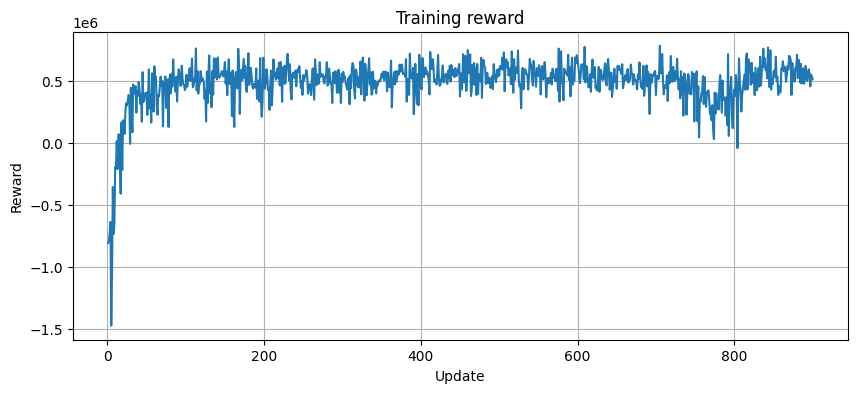

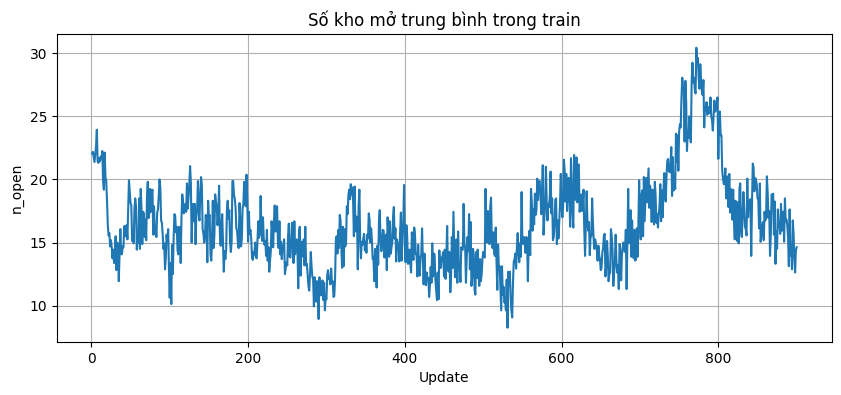

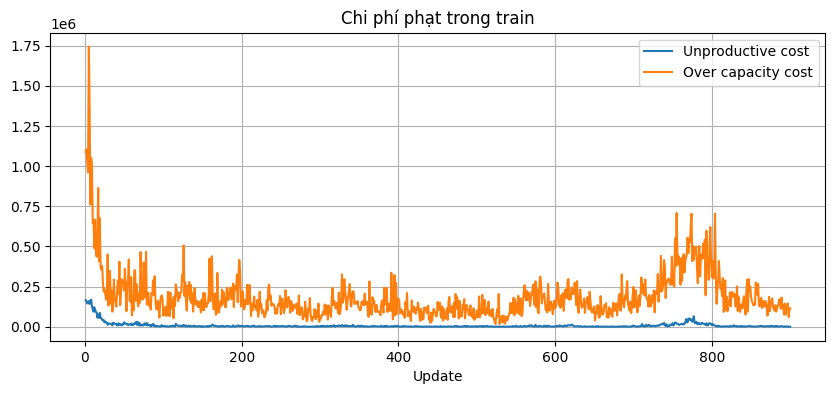

,method,scenario,reward,n_open,served_demand,unserved_demand,coverage_ratio,unserved_ratio,capacity_ratio,utilization_ratio,...,unserved_cost,overlap_cost,over_capacity_cost,utilization_bonus,unproductive_warehouse_cost,avg_served_demand_per_open_warehouse,min_served_demand_by_open_warehouse,avg_transport_multiplier,profit,update
67,Random,0.5,306155.053783,22.111111,20442.604329,32933.129395,0.414939,0.585061,2.448502,0.418573,...,0.0,1993.165225,355733.649911,20928.659365,51383.464383,920.861016,215.503393,0.957387,306155.053783,850
68,Greedy,0.5,622976.112041,15.388889,18094.061618,35281.672106,0.305694,0.694306,1.712526,0.630274,...,0.0,2413.446124,70599.493134,31513.717830,0.000000,1386.603563,940.534092,0.880715,622976.112041,900
69,MAPPO,0.5,740565.883354,18.777778,21938.580132,31437.153592,0.407833,0.592167,1.882468,0.535944,...,0.0,1413.867522,82536.046563,26797.201844,396.156684,1179.076914,553.531279,0.925228,740565.883354,900
70,MAPPO + Local Search,0.5,795708.853734,19.555556,23156.185276,30219.548448,0.442797,0.557203,1.861425,0.540145,...,0.0,1057.514927,73081.139186,27007.252530,0.000000,1188.319119,629.185577,0.933832,795708.853734,900
71,Random,0.5,300519.760660,22.888889,21026.644911,32349.088813,0.419016,0.580984,2.482374,0.412192,...,0.0,2047.835125,375558.556384,20609.618613,56031.721544,906.823235,200.769485,0.954302,300519.760660,900


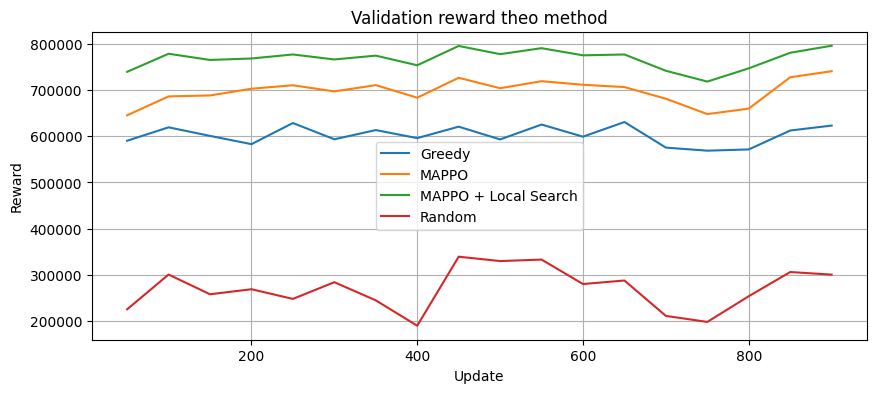

In [13]:
train_df = pd.DataFrame(train_log)
train_df.to_csv(LOG_DIR / "train_log.csv", index=False, encoding="utf-8-sig")
display(train_df.tail())

plt.figure(figsize=(10, 4))
plt.plot(train_df["update"], train_df["reward"])
plt.title("Training reward")
plt.xlabel("Update")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(train_df["update"], train_df["n_open"])
plt.title("Số kho mở trung bình trong train")
plt.xlabel("Update")
plt.ylabel("n_open")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(train_df["update"], train_df["unproductive_warehouse_cost"], label="Unproductive cost")
plt.plot(train_df["update"], train_df["over_capacity_cost"], label="Over capacity cost")
plt.title("Chi phí phạt trong train")
plt.xlabel("Update")
plt.legend()
plt.grid(True)
plt.show()

val_path = LOG_DIR / "val_log.csv"
if val_path.exists():
    val_df = pd.read_csv(val_path)
    display(val_df.tail())
    plt.figure(figsize=(10, 4))
    for method in val_df["method"].unique():
        tmp = val_df[val_df["method"] == method]
        plt.plot(tmp["update"], tmp["reward"], label=method)
    plt.title("Validation reward theo method")
    plt.xlabel("Update")
    plt.ylabel("Reward")
    plt.legend()
    plt.grid(True)
    plt.show()

## 13. Test cuối cùng bằng best model

In [14]:
if best_actor_path.exists():
    actor.load_state_dict(torch.load(best_actor_path, map_location=DEVICE))
    print("Loaded best actor:", best_actor_path)

if best_critic_path.exists():
    critic.load_state_dict(torch.load(best_critic_path, map_location=DEVICE))
    print("Loaded best critic:", best_critic_path)

test_detail, test_summary = evaluate_methods_on_provinces(TEST_PROVINCES, scenarios_per_province=TEST_SCENARIOS_PER_PROVINCE, policy_samples=POLICY_SAMPLES)
test_detail.to_csv(LOG_DIR / "test_detail.csv", index=False, encoding="utf-8-sig")
test_summary.to_csv(LOG_DIR / "test_summary.csv", index=False, encoding="utf-8-sig")

display(test_summary.sort_values("reward", ascending=False))
display(test_detail.head())

Loaded best actor: models/best_mappo_actor.pt
Loaded best critic: models/best_mappo_critic.pt


,method,scenario,reward,n_open,served_demand,unserved_demand,coverage_ratio,unserved_ratio,capacity_ratio,utilization_ratio,...,distance_cost,unserved_cost,overlap_cost,over_capacity_cost,utilization_bonus,unproductive_warehouse_cost,avg_served_demand_per_open_warehouse,min_served_demand_by_open_warehouse,avg_transport_multiplier,profit
2,MAPPO + Local Search,1.5,774566.500078,17.825,21756.249817,26875.496765,0.469513,0.530487,1.751123,0.577335,...,112130.426074,0.0,1148.124189,50580.809951,28866.727716,3.358269,1270.136023,643.200307,0.911676,774566.500078
1,MAPPO,1.5,727068.351746,17.525,20903.901147,27727.845435,0.441627,0.558373,1.771823,0.577747,...,105578.156641,0.0,1724.466369,64281.890701,28887.351296,179.543211,1271.043442,663.741491,0.901423,727068.351746
0,Greedy,1.5,628117.914181,15.175,18078.015424,30553.731158,0.361521,0.638479,1.731134,0.606103,...,86884.825732,0.0,2844.123340,64579.241900,30305.154645,29.820671,1333.426816,883.637897,0.876707,628117.914181
3,Random,1.5,-365113.288635,22.975,19919.502490,28712.244092,0.464608,0.535392,2.872868,0.383136,...,103266.936914,0.0,2403.884479,931357.147312,19156.793016,113467.237457,842.898892,168.821084,0.941852,-365113.288635


,province,scenario,method,reward,n_open,served_demand,unserved_demand,coverage_ratio,unserved_ratio,capacity_ratio,...,distance_cost,unserved_cost,overlap_cost,over_capacity_cost,utilization_bonus,unproductive_warehouse_cost,avg_served_demand_per_open_warehouse,min_served_demand_by_open_warehouse,avg_transport_multiplier,profit
0,TháiBình,0,Random,7.989022e+05,29,28678.128906,28972.007812,0.497451,0.502549,2.224692,...,164902.312500,0.0,3654.659748,198922.321974,22475.022654,0.0,988.900940,408.612030,1.017576,7.989022e+05
1,TháiBình,0,Greedy,8.121341e+05,25,26489.609375,31160.527344,0.459489,0.540511,2.076286,...,144665.125000,0.0,4615.062237,137147.679406,24081.463068,0.0,1059.584351,637.295898,0.990637,8.121341e+05
2,TháiBình,0,MAPPO,1.022204e+06,30,32212.312500,25437.824219,0.558755,0.441245,2.048906,...,183508.203125,0.0,2305.036902,127002.091171,24403.267045,0.0,1073.743774,553.368164,1.010939,1.022204e+06
3,TháiBình,0,MAPPO + Local Search,1.093194e+06,34,35331.230469,22318.906250,0.612856,0.387144,2.117107,...,201348.062500,0.0,2638.228607,152997.871424,23617.132666,0.0,1039.153809,553.368164,1.016022,1.093194e+06
4,TháiBình,1,Random,9.040898e+05,28,29405.648438,28244.488281,0.510071,0.489929,2.094836,...,163375.703125,0.0,2442.264509,144242.829163,23868.221134,0.0,1050.201538,402.823975,0.998393,9.040898e+05


## 14. Lưu config/model cuối cùng

In [15]:
config = {
    "algorithm": "MAPPO-style CTDE",
    "training_scope": "Vietnam province-level demand raster",
    "use_all_provinces": USE_ALL_PROVINCES,
    "n_train_agents": N_TRAIN_AGENTS,
    "n_pool_per_province": N_POOL_PER_PROVINCE,
    "service_radius_km": SERVICE_RADIUS_KM,
    "obs_dim": OBS_DIM,
    "feature_cols": feature_cols,
    "projected_crs": PROJECTED_CRS,
    "train_provinces": TRAIN_PROVINCES,
    "val_provinces": VAL_PROVINCES,
    "test_provinces": TEST_PROVINCES,
    "reward": {
        "revenue_per_demand": REVENUE_PER_DEMAND,
        "default_opening_cost": DEFAULT_OPENING_COST,
        "warehouse_capacity": WAREHOUSE_CAPACITY,
        "distance_cost": DISTANCE_COST,
        "unserved_cost": UNSERVED_COST,
        "overlap_cost": OVERLAP_COST,
        "transport_multiplier_min": TRANSPORT_MULTIPLIER_MIN,
        "transport_multiplier_max": TRANSPORT_MULTIPLIER_MAX,
        "over_capacity_ratio_max": OVER_CAPACITY_RATIO_MAX,
        "over_capacity_penalty": OVER_CAPACITY_PENALTY,
        "utilization_bonus": UTILIZATION_BONUS,
        "min_served_demand_per_open_warehouse": MIN_SERVED_DEMAND_PER_OPEN_WAREHOUSE,
        "min_revenue_to_open_cost_ratio": MIN_REVENUE_TO_OPEN_COST_RATIO,
        "unproductive_warehouse_penalty": UNPRODUCTIVE_WAREHOUSE_PENALTY
    },
    "best_update": best_update,
    "best_val_reward": best_val_reward
}

with open(MODEL_DIR / "best_mappo_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=4)

torch.save(actor.state_dict(), MODEL_DIR / "last_mappo_actor.pt")
torch.save(critic.state_dict(), MODEL_DIR / "last_mappo_critic.pt")

print("Saved:")
print(MODEL_DIR / "best_mappo_actor.pt")
print(MODEL_DIR / "best_mappo_critic.pt")
print(MODEL_DIR / "best_mappo_config.json")
print(LOG_DIR / "train_log.csv")
print(LOG_DIR / "val_log.csv")
print(LOG_DIR / "test_summary.csv")

try:
    from google.colab import files
    files.download(MODEL_DIR / "best_mappo_actor.pt")
    files.download(MODEL_DIR / "best_mappo_critic.pt")
    files.download(MODEL_DIR / "best_mappo_config.json")
    files.download(LOG_DIR / "train_log.csv")
    files.download(LOG_DIR / "val_log.csv")
    files.download(LOG_DIR / "test_summary.csv")
except Exception:
    print("Không chạy trên Colab hoặc không tải tự động. Tải từ panel Files bên trái.")

Saved:
models/best_mappo_actor.pt
models/best_mappo_critic.pt
models/best_mappo_config.json
logs/train_log.csv
logs/val_log.csv
logs/test_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. Tạo bản đồ kiểm thử cho một tỉnh trong test

In [18]:
def create_result_map_for_scenario(province_name, warehouses, actions, info, output_html):
    province_gdf = get_province_geometry(province_name)
    center = province_gdf.to_crs(epsg=4326).geometry.centroid.iloc[0]
    m = folium.Map(location=[center.y, center.x], zoom_start=9, tiles="OpenStreetMap")

    folium.GeoJson(
        province_gdf.to_crs(epsg=4326),
        name="Ranh giới tỉnh/thành",
        style_function=lambda x: {"fillColor": "transparent", "color": "black", "weight": 2, "fillOpacity": 0}
    ).add_to(m)
        # =========================
    # Hiển thị các ô demand trên bản đồ
    # =========================

    cache = get_full_cache(province_name)
    demand_cells = cache["demand_cells"].to_crs(epsg=4326).copy()

    def demand_color(level):
        if level == 1:
            return "#ffffb2"
        elif level == 2:
            return "#fecc5c"
        elif level == 3:
            return "#fd8d3c"
        elif level == 4:
            return "#f03b20"
        elif level == 5:
            return "#bd0026"
        else:
            return "#ffffff"

    folium.GeoJson(
        demand_cells,
        name="Demand cells",
        style_function=lambda feature: {
            "fillColor": demand_color(feature["properties"]["demand_level"]),
            "color": "transparent",
            "weight": 0,
            "fillOpacity": 0.45,
        },
        tooltip=folium.GeoJsonTooltip(
            fields=["demand_level", "demand", "density"],
            aliases=["Mức demand:", "Demand:", "Mật độ dân số:"],
            localize=True
        )
    ).add_to(m)

    result = warehouses.copy()
    result["open"] = actions

    for _, row in result.iterrows():
        is_open = int(row["open"]) == 1
        color = "green" if is_open else "gray"
        status = "MỞ" if is_open else "KHÔNG MỞ"
        folium.Marker(
            location=[row["lat"], row["lon"]],
            popup=f"{row['warehouse_id']}<br>{status}<br>Cost: {row['opening_cost']:.0f}<br>Capacity: {row['capacity']:.0f}",
            icon=folium.Icon(color=color, icon="home", prefix="fa")
        ).add_to(m)

        if is_open:
            folium.Circle(
                location=[row["lat"], row["lon"]],
                radius=SERVICE_RADIUS_KM * 1000,
                color="green",
                fill=False,
                weight=2
            ).add_to(m)

    legend_html = (
        "<div style='position: fixed; bottom: 50px; left: 50px; width: 360px; height: 260px; "
        "background-color: white; z-index:9999; font-size:14px; border:2px solid grey; padding: 10px;'>"
        f"<b>{province_name}</b><br>"
        "Method: MAPPO + Local Search<br>"
        f"Kho mở: {int(result['open'].sum())}/{len(result)}<br>"
        f"Profit: {info['profit']:,.0f}<br>"
        f"Served demand: {info['served_demand']:,.0f}<br>"
        f"Coverage: {info['coverage_ratio']:.2%}<br>"
        f"Transport cost: {info['distance_cost']:,.0f}<br>"
        f"Unproductive cost: {info['unproductive_warehouse_cost']:,.0f}<br>"
        f"Over capacity cost: {info['over_capacity_cost']:,.0f}<br>"
        "</div>"
    )

    m.get_root().html.add_child(folium.Element(legend_html))
    folium.LayerControl().add_to(m)
    m.save(output_html)
    return m

province = TEST_PROVINCES[0] if len(TEST_PROVINCES) > 0 else VAL_PROVINCES[0]
cache = get_full_cache(province)
pool = cache["warehouse_pool"]
selected_idx = np.random.choice(len(pool), size=N_TRAIN_AGENTS, replace=False)
selected_idx = np.sort(selected_idx)

warehouses, env, features, _ = build_env_from_pool_sample(province, selected_idx)
m_actions, m_reward, m_info, probs = mappo_decide(features, env, n_samples=POLICY_SAMPLES)
ml_actions, ml_reward, ml_info = cooperative_local_search(m_actions, env, max_iter=LOCAL_SEARCH_MAX_ITER)

map_path = OUTPUT_DIR / "test_province_mappo_map.html"
m = create_result_map_for_scenario(province, warehouses, ml_actions, ml_info, map_path)

result_df = warehouses.copy()
result_df["open_probability"] = probs
result_df["open"] = ml_actions
result_df.to_csv(OUTPUT_DIR / "test_province_decision.csv", index=False, encoding="utf-8-sig")

print("Saved map:", map_path)
display(result_df.head())
m

Saved map: outputs/test_province_mappo_map.html


,lat,lon,warehouse_id,opening_cost,capacity,open_probability,open
0,20.522822,106.237422,Pool_Kho_2,10000.0,2200.0,0.956254,1
1,20.428750,106.345927,Pool_Kho_4,10000.0,2200.0,0.194823,0
2,20.635624,106.155023,Pool_Kho_8,10000.0,2200.0,0.226359,1
3,20.433432,106.254639,Pool_Kho_10,10000.0,2200.0,0.356027,0
4,20.527886,106.417179,Pool_Kho_16,10000.0,2200.0,0.229490,0


In [23]:
# =========================
# TEST MỘT TỈNH/TRÊN BẢN ĐỒ
# =========================

def test_province_on_map(province_name, n_warehouses=50, policy_samples=300):
    print("Đang test trên bản đồ:", province_name)

    # Load best actor đã train
    best_actor_path = MODEL_DIR / "best_mappo_actor.pt"

    if best_actor_path.exists():
        actor.load_state_dict(torch.load(best_actor_path, map_location=DEVICE))
        actor.eval()
        print("Đã load best actor:", best_actor_path)
    else:
        print("Không tìm thấy best_mappo_actor.pt, dùng actor hiện tại trong runtime.")

    # Load dữ liệu tỉnh
    cache = get_full_cache(province_name)
    pool = cache["warehouse_pool"]

    n_warehouses = min(n_warehouses, len(pool))

    # Lấy ngẫu nhiên n kho ứng viên từ pool của tỉnh
    selected_idx = np.random.choice(
        len(pool),
        size=n_warehouses,
        replace=False
    )

    selected_idx = np.sort(selected_idx)

    warehouses, env, features, _ = build_env_from_pool_sample(
        province_name,
        selected_idx
    )

    # MAPPO sinh phương án
    m_actions, m_reward, m_info, probs = mappo_decide(
        features,
        env,
        n_samples=policy_samples
    )

    # Local Search tinh chỉnh
    ml_actions, ml_reward, ml_info = cooperative_local_search(
        m_actions,
        env,
        max_iter=LOCAL_SEARCH_MAX_ITER
    )

    # Lưu kết quả
    result_df = warehouses.copy()
    result_df["open_probability"] = probs
    result_df["open"] = ml_actions

    output_csv = OUTPUT_DIR / f"{safe_name(province_name)}_decision.csv"
    output_map = OUTPUT_DIR / f"{safe_name(province_name)}_map.html"

    result_df.to_csv(
        output_csv,
        index=False,
        encoding="utf-8-sig"
    )

    # Vẽ bản đồ
    m = create_result_map_for_scenario(
        province_name,
        warehouses,
        ml_actions,
        ml_info,
        output_map
    )

    print("MAPPO reward:", m_reward)
    print("MAPPO + Local Search reward:", ml_reward)
    print("Số kho mở:", int(result_df["open"].sum()), "/", len(result_df))
    print("Đã lưu CSV:", output_csv)
    print("Đã lưu bản đồ HTML:", output_map)

    display(pd.DataFrame([ml_info]))
    display(result_df)

    return result_df, ml_info, m

In [25]:
result_df, info, m = test_province_on_map(
    province_name="BắcNinh",
    n_warehouses=50,
    policy_samples=300
)

m

Đang test trên bản đồ: BắcNinh
Đã load best actor: models/best_mappo_actor.pt
MAPPO reward: 277491.35787615826
MAPPO + Local Search reward: 338236.3489200338
Số kho mở: 9 / 50
Đã lưu CSV: outputs/bacninh_decision.csv
Đã lưu bản đồ HTML: outputs/bacninh_map.html


,n_open,served_demand,unserved_demand,coverage_ratio,unserved_ratio,capacity_ratio,utilization_ratio,revenue,opening_cost,distance_cost,unserved_cost,overlap_cost,over_capacity_cost,utilization_bonus,unproductive_warehouse_cost,avg_served_demand_per_open_warehouse,min_served_demand_by_open_warehouse,avg_transport_multiplier,profit
0,9,10594.088867,11186.395508,0.486403,0.513597,1.868967,0.535055,529704.443359,90000.0,57846.910156,0.0,349.043077,70024.89087,26752.749665,0.0,1177.121094,819.003296,0.976241,338236.34892


,lat,lon,warehouse_id,opening_cost,capacity,open_probability,open
0,21.189992,106.061250,Pool_Kho_5,10000.0,2200.0,0.326280,0
1,21.046627,106.145757,Pool_Kho_7,10000.0,2200.0,0.082920,0
2,21.200421,106.008520,Pool_Kho_9,10000.0,2200.0,0.074639,1
3,21.206353,105.951735,Pool_Kho_11,10000.0,2200.0,0.119270,0
4,21.174583,106.077916,Pool_Kho_13,10000.0,2200.0,0.829037,0
5,21.011960,106.173003,Pool_Kho_14,10000.0,2200.0,0.127989,0
6,21.056413,106.199867,Pool_Kho_32,10000.0,2200.0,0.059269,0
7,21.037083,106.097759,Pool_Kho_38,10000.0,2200.0,0.031032,0
8,21.084043,105.972832,Pool_Kho_40,10000.0,2200.0,0.013015,0
9,21.078750,106.058746,Pool_Kho_42,10000.0,2200.0,0.147187,0
